# RegimeShift: Hidden Markov Model Based Dynamic Asset Allocation

## Summer of Quant – Advanced Project

### Objective

This project builds a dynamic asset allocation system that detects hidden market regimes
(Bull, Bear and Crisis) using a Hidden Markov Model (HMM) and automatically rebalances
a multi-asset portfolio consisting of Indian equities, Gold and Bonds.

The project follows the official Summer of Quant Advanced Project Statement.

Pipeline:

Data Collection
→ Feature Engineering
→ Hidden Markov Model
→ Regime Detection
→ Walk-Forward Validation
→ Portfolio Optimisation
→ Transaction Cost Modelling
→ Backtesting
→ Performance Evaluation

<br>

Submitted By:- <br>
Name: Tathagata Roy <br>
Roll No.: 25B3954


# 1. Installing Required Libraries

This notebook uses the following libraries:

- yfinance
- hmmlearn
- cvxpy
- pandas
- numpy
- matplotlib
- scipy
- scikit-learn

In [1]:
# Install required packages

!pip -q install yfinance
!pip -q install hmmlearn
!pip -q install cvxpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.7 MB/s eta 0:00:00


# 2. Import Required Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import cvxpy as cp
from scipy import stats
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

np.random.seed(42)

In [3]:
print("All libraries imported successfully.")

All libraries imported successfully.


# 3. Download Historical Market Data

The first step is to collect daily historical prices for the assets used in this project.

The portfolio consists of three asset classes:

- Indian equities represented by the NIFTY 50 Index
- Gold represented by a Gold ETF
- Government bonds represented by a Bond ETF

The India VIX is also downloaded as an additional market feature since it reflects the level of fear and uncertainty in the market.

All data is obtained using the yfinance library.

In [4]:
# Date range for the study
from datetime import datetime

START_DATE = "2012-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

In [5]:
# Asset universe used in this project

TICKERS = {
    "NIFTY": "^NSEI",
    "GOLD": "GOLDBEES.NS",
    "BOND": "LIQUIDBEES.NS",
    "VIX": "^INDIAVIX"
}

In [6]:
# Download adjusted closing prices

price_data = pd.DataFrame()

for asset, ticker in TICKERS.items():
    data = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        progress=False,
        auto_adjust=True
    )

    if data.empty:
        print(f"{asset}: Download failed")
    else:
        price_data[asset] = data["Close"]

print("Download completed.")

Download completed.


In [7]:
price_data.head()

,NIFTY,GOLD,BOND,VIX
Date,,,,
2012-01-03,4765.299805,26.446501,589.801514,26.160000
2012-01-04,4749.649902,26.659000,589.795532,26.410000
2012-01-05,4749.950195,26.639999,589.795532,25.910000
2012-01-06,4754.100098,26.742001,589.801514,25.459999
2012-01-09,4742.799805,26.542999,589.795532,25.680000


In [8]:
price_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3574 entries, 2012-01-03 to 2026-07-24
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NIFTY   3574 non-null   float64
 1   GOLD    3573 non-null   float64
 2   BOND    3573 non-null   float64
 3   VIX     3557 non-null   float64
dtypes: float64(4)
memory usage: 139.6 KB


In [9]:
price_data.tail()

,NIFTY,GOLD,BOND,VIX
Date,,,,
2026-07-20,24238.500000,116.839996,1000.00000,12.98
2026-07-21,24187.699219,117.730003,1000.00000,12.60
2026-07-22,23996.250000,119.139999,1000.00000,13.29
2026-07-23,23869.599609,118.690002,999.98999,13.48
2026-07-24,23767.449219,117.910004,999.98999,14.03


# 4. Data Cleaning

The data is aligned by date and missing values are handled before further analysis.

In [10]:
# Check missing values

price_data.isna().sum()

,0
NIFTY,0
GOLD,1
BOND,1
VIX,17


In [11]:
# Forward fill missing values

price_data = price_data.ffill()

In [12]:
# Remove any remaining missing values

price_data = price_data.dropna()

print(f"Number of observations: {len(price_data)}")

Number of observations: 3574


In [13]:
# Verify that no missing values remain

price_data.isna().sum()

,0
NIFTY,0
GOLD,0
BOND,0
VIX,0


# 5. Exploratory Data Analysis

The price series are plotted to understand their overall behaviour before feature engineering.

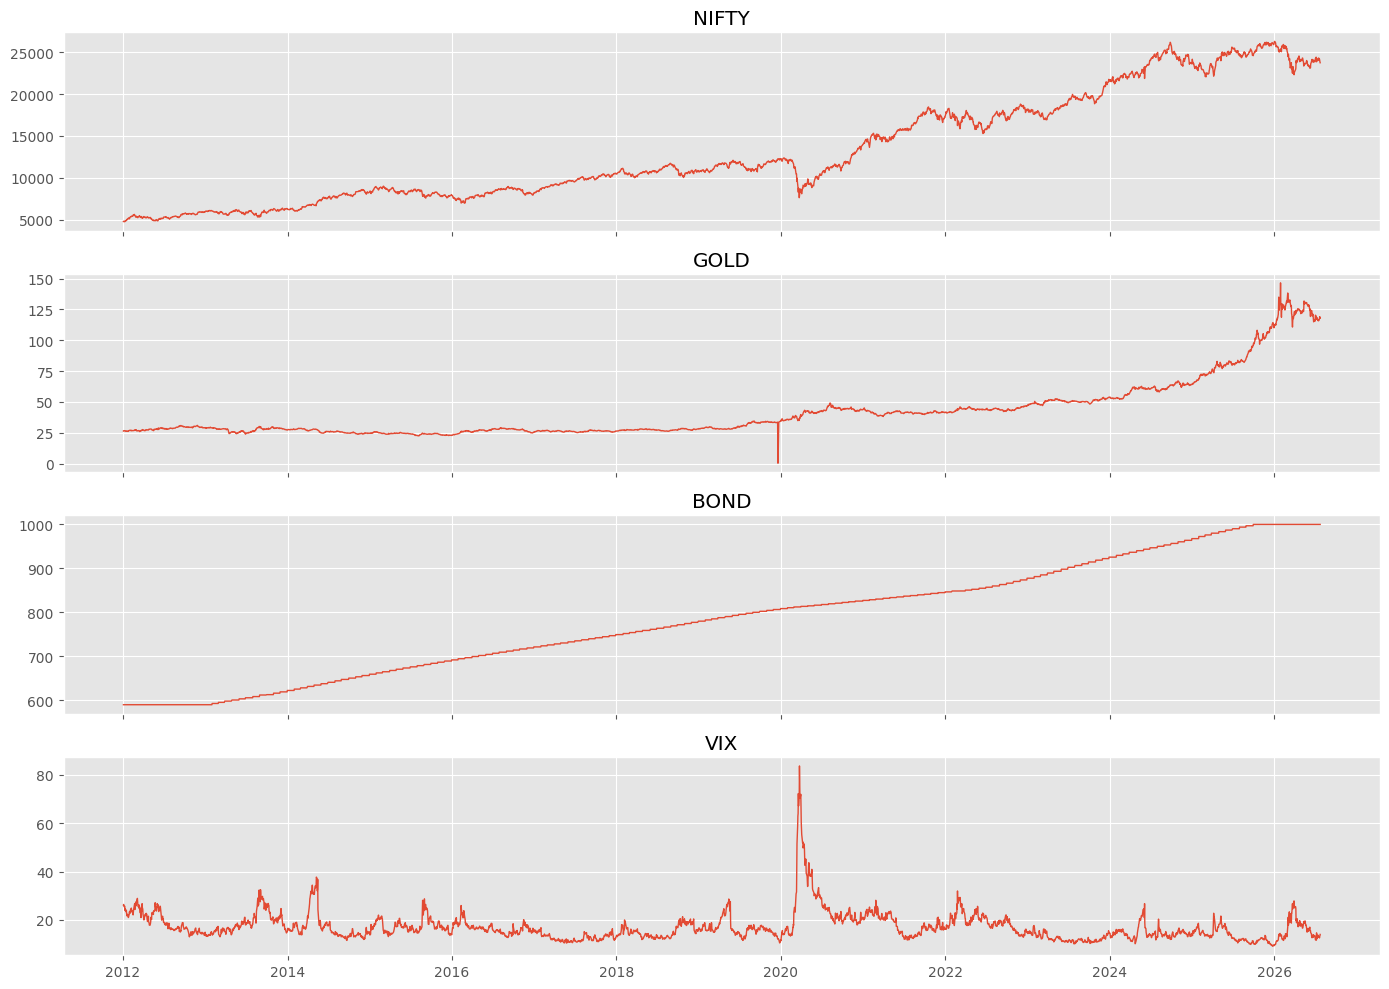

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, column in zip(axes, price_data.columns):
    ax.plot(price_data.index, price_data[column], linewidth=1)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [15]:
price_data.describe().T

,count,mean,std,min,25%,50%,75%,max
NIFTY,3574.0,13204.223427,6412.546462,4742.799805,8126.912476,10944.899902,17916.363281,26328.550781
GOLD,3574.0,41.893397,23.524718,0.335500,26.808751,29.830000,46.669999,146.529999
BOND,3574.0,784.307473,125.470049,589.795532,681.374084,789.115051,873.702637,1000.000000
VIX,3574.0,17.032625,5.892185,9.150000,13.580000,15.800000,18.889999,83.610001


# 6. Daily Returns

Daily returns are computed from adjusted closing prices. These returns are used throughout the rest of the project.

In [16]:
# Compute daily returns

returns = price_data.pct_change().dropna()

In [17]:
returns.head()

,NIFTY,GOLD,BOND,VIX
Date,,,,
2012-01-04,-0.003284,0.008035,-0.00001,0.009557
2012-01-05,0.000063,-0.000713,0.00000,-0.018932
2012-01-06,0.000874,0.003829,0.00001,-0.017368
2012-01-09,-0.002377,-0.007442,-0.00001,0.008641
2012-01-10,0.022508,-0.007102,0.00000,-0.065421


In [18]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
NIFTY,3573.0,0.000502,0.010151,-0.129805,-0.004435,0.000659,0.005932,0.087632
GOLD,3573.0,0.027897,1.656331,-0.990014,-0.004161,0.000187,0.005002,99.000008
BOND,3573.0,0.000148,0.000731,-0.000879,0.000000,0.000000,0.000000,0.005832
VIX,3573.0,0.001219,0.053940,-0.339407,-0.026751,-0.003100,0.023678,0.656250


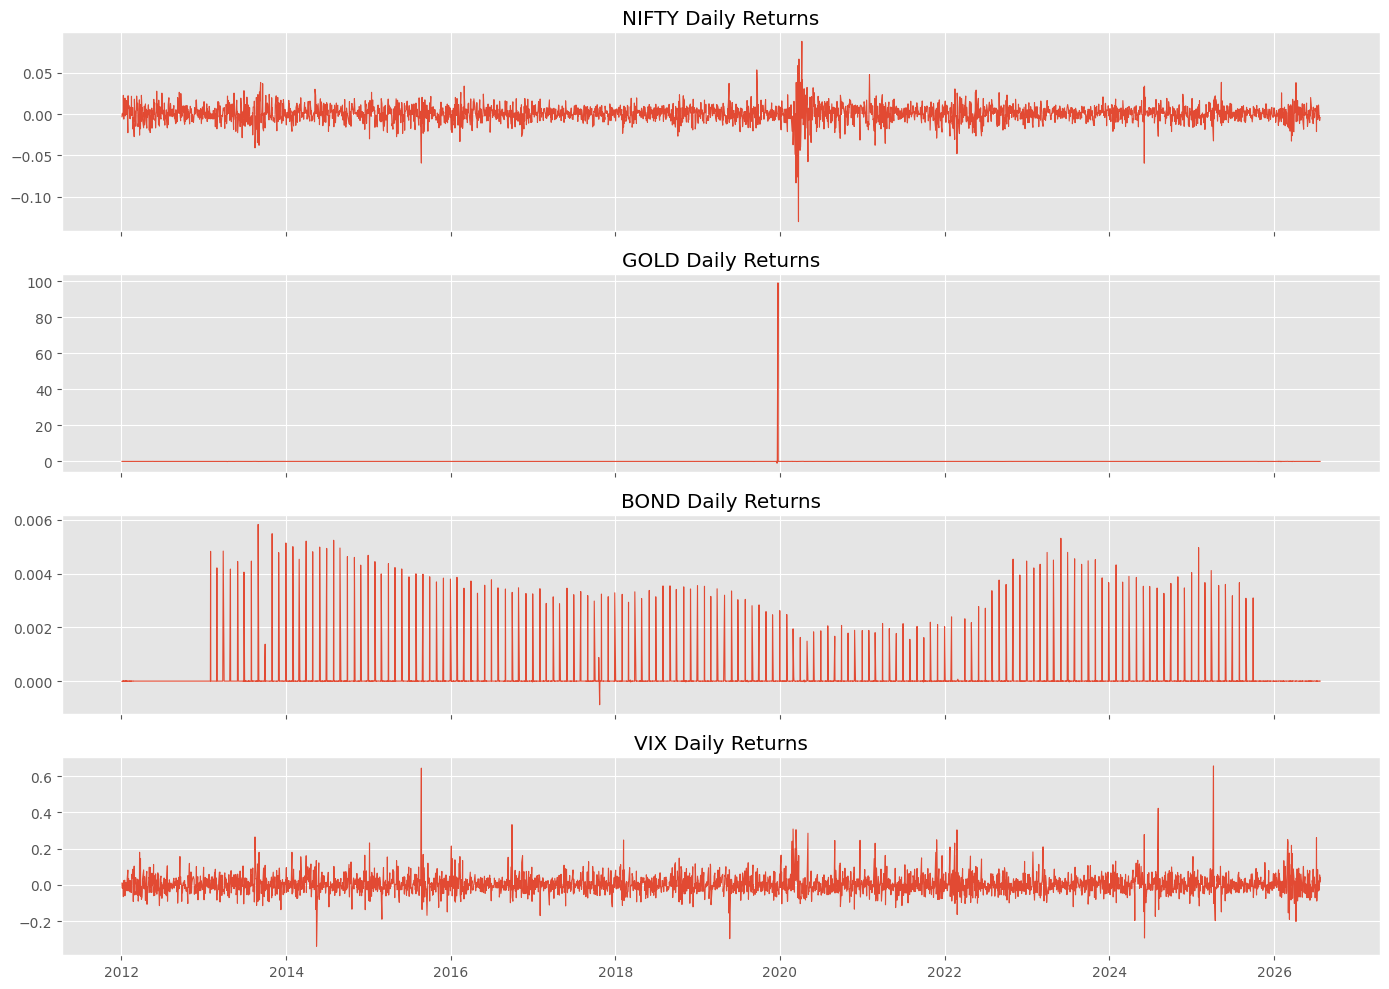

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

for ax, column in zip(axes, returns.columns):
    ax.plot(returns.index, returns[column], linewidth=0.8)
    ax.set_title(f"{column} Daily Returns")

plt.tight_layout()
plt.show()

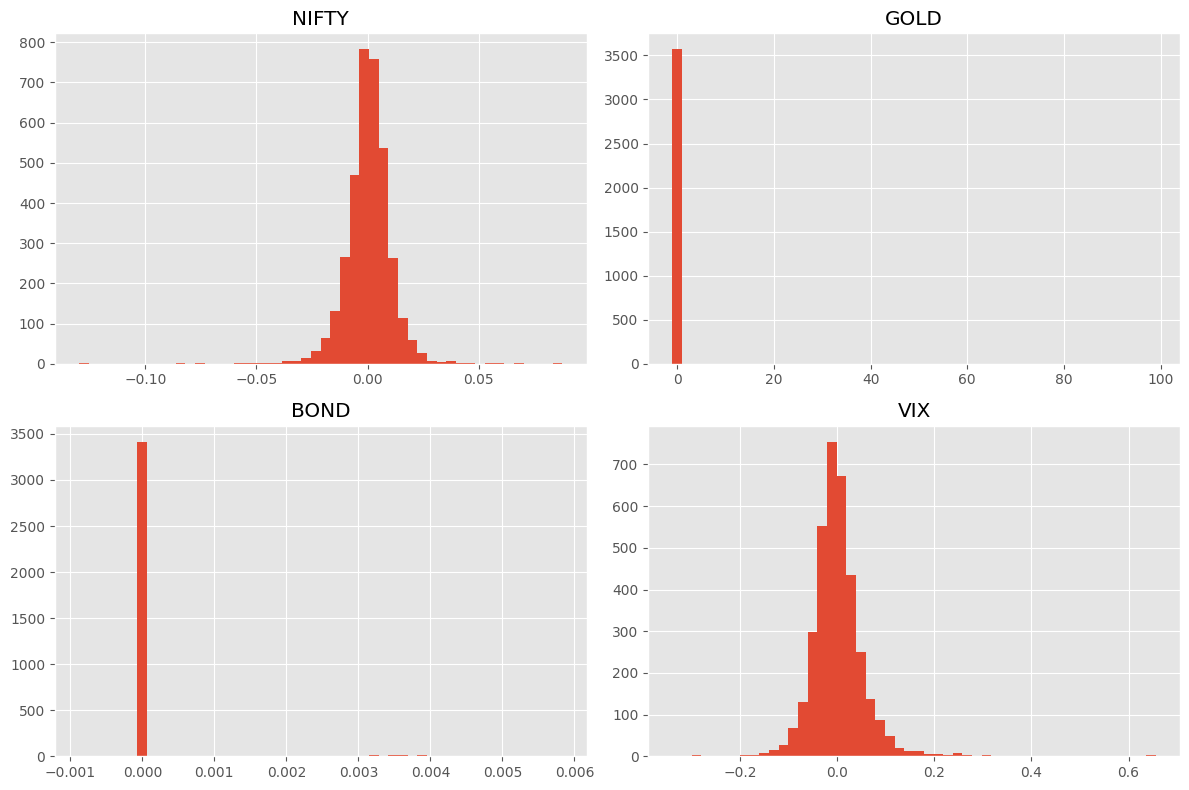

In [20]:
returns.hist(figsize=(12, 8), bins=50)

plt.tight_layout()
plt.show()

# 7. Return Cleaning

Extreme return values caused by ETF adjustments are removed before feature engineering.

In [21]:
# Inspect the largest absolute returns

returns["GOLD"].abs().sort_values(ascending=False).head(10)

,GOLD
Date,
2019-12-23,99.000008
2019-12-19,0.990014
2026-01-30,0.105166
2026-02-02,0.094951
2026-03-23,0.085412
2026-01-29,0.078854
2026-01-22,0.078758
2013-04-15,0.076554
2026-01-21,0.072382


In [22]:
# Remove unrealistic daily returns

returns.loc[returns["GOLD"].abs() > 0.30, "GOLD"] = np.nan

# Forward fill the missing return

returns = returns.ffill()

In [23]:
returns["GOLD"].describe()

,GOLD
count,3573.000000
mean,0.000468
std,0.009726
min,-0.105166
25%,-0.004155
50%,0.000189
75%,0.004984
max,0.078854


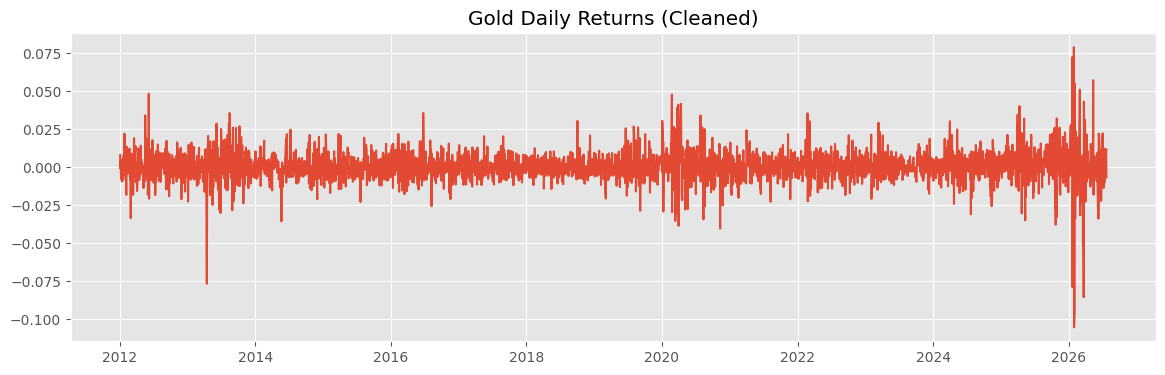

In [24]:
plt.figure(figsize=(14,4))

plt.plot(returns.index, returns["GOLD"])

plt.title("Gold Daily Returns (Cleaned)")

plt.show()

# 8. Feature Engineering

Momentum and volatility features are created from the NIFTY index. The India VIX is included as a measure of market uncertainty.

In [25]:
features = pd.DataFrame(index=returns.index)

# Daily return
features["ret"] = returns["NIFTY"]

# 1 week momentum
features["mom_5"] = price_data["NIFTY"].pct_change(5)

# 1 month momentum
features["mom_21"] = price_data["NIFTY"].pct_change(21)

# 3 month momentum
features["mom_63"] = price_data["NIFTY"].pct_change(63)

# 20 day rolling volatility
features["vol_20"] = returns["NIFTY"].rolling(20).std()

# India VIX
features["vix"] = price_data["VIX"]

features = features.dropna()

In [26]:
features = features.dropna()

features.head()

,ret,mom_5,mom_21,mom_63,vol_20,vix
Date,,,,,,
2012-04-04,-0.006644,0.024669,0.008058,0.117013,0.013360,20.629999
2012-04-09,-0.016626,0.010726,0.002298,0.102060,0.013932,22.330000
2012-04-10,0.001758,-0.009810,0.004434,0.103927,0.013000,21.920000
2012-04-11,-0.003194,-0.017121,-0.020005,0.099440,0.012940,22.290001
2012-04-12,0.009566,-0.015237,-0.015430,0.112602,0.012761,21.780001


In [27]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
ret,3511.0,0.000476,0.010118,-0.129805,-0.004432,0.000625,0.005860,0.087632
mom_5,3511.0,0.002419,0.022545,-0.190239,-0.010029,0.003363,0.015921,0.107031
mom_21,3511.0,0.010209,0.046082,-0.372397,-0.014502,0.011359,0.039327,0.219710
mom_63,3511.0,0.030832,0.079226,-0.379859,-0.018575,0.038038,0.080285,0.364344
vol_20,3511.0,0.008964,0.004720,0.003169,0.006272,0.008054,0.010087,0.055963
vix,3511.0,16.903275,5.858722,9.150000,13.530000,15.720000,18.670000,83.610001


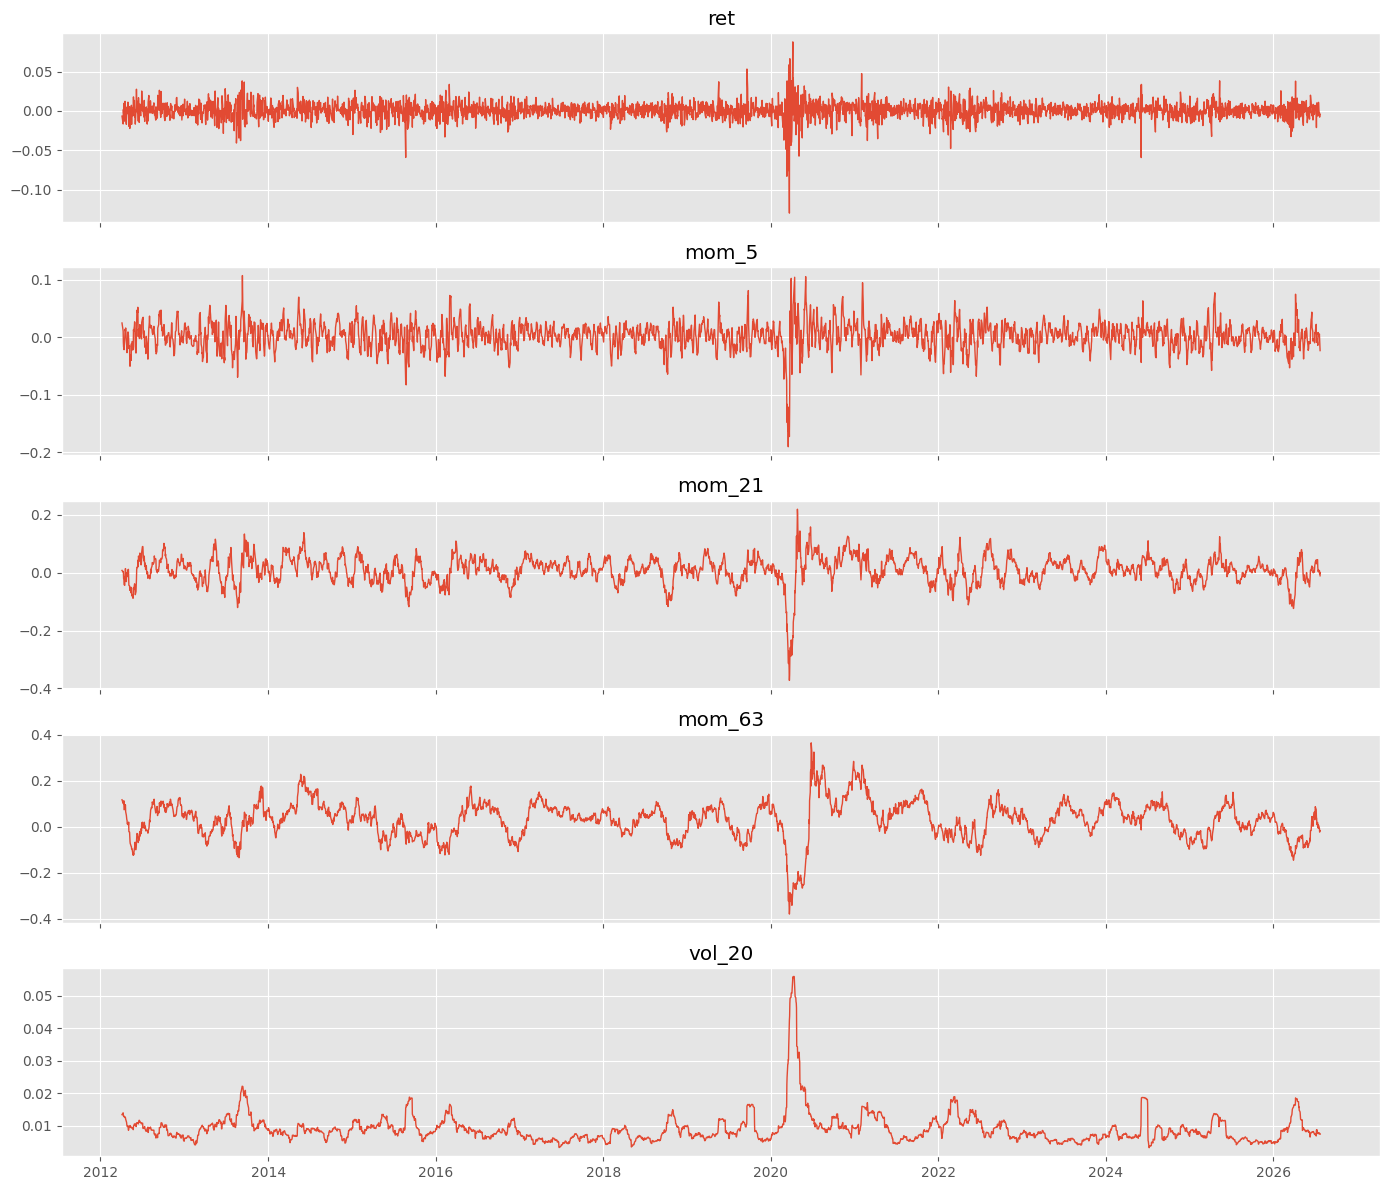

In [28]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

for ax, column in zip(axes, features.columns):
    ax.plot(features.index, features[column], linewidth=1)
    ax.set_title(column)

plt.tight_layout()
plt.show()

In [29]:
features.isna().sum()

,0
ret,0
mom_5,0
mom_21,0
mom_63,0
vol_20,0
vix,0


# 9. Hidden Markov Model

The feature matrix is standardised and used to train a three-state Gaussian Hidden Markov Model.

In [30]:
# Standardise the features

scaler = StandardScaler()

X = scaler.fit_transform(features)

In [31]:
# Train the HMM

hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=500,
    random_state=42
)

hmm.fit(X)

GaussianHMM(covariance_type='full', n_components=3, n_iter=500, random_state=42)

In [32]:
# Predict hidden states

hidden_states = hmm.predict(X)

features["state"] = hidden_states

In [33]:
features.head()

,ret,mom_5,mom_21,mom_63,vol_20,vix,state
Date,,,,,,,
2012-04-04,-0.006644,0.024669,0.008058,0.117013,0.013360,20.629999,2
2012-04-09,-0.016626,0.010726,0.002298,0.102060,0.013932,22.330000,1
2012-04-10,0.001758,-0.009810,0.004434,0.103927,0.013000,21.920000,1
2012-04-11,-0.003194,-0.017121,-0.020005,0.099440,0.012940,22.290001,1
2012-04-12,0.009566,-0.015237,-0.015430,0.112602,0.012761,21.780001,1


In [34]:
print("Transition Probability Matrix")

transition_matrix = pd.DataFrame(
    hmm.transmat_,
    index=[f"State {i}" for i in range(3)],
    columns=[f"State {i}" for i in range(3)]
)

transition_matrix

Transition Probability Matrix


,State 0,State 1,State 2
State 0,0.978109,0.021891,1.032213e-69
State 1,0.021237,0.970299,8.464632e-03
State 2,0.002566,0.037115,9.603192e-01


In [35]:
state_summary = (
    features
    .groupby("state")[["ret", "mom_5", "mom_21", "mom_63", "vol_20", "vix"]]
    .mean()
)

state_summary

,ret,mom_5,mom_21,mom_63,vol_20,vix
state,,,,,,
0,0.000615,0.003879,0.014128,0.056960,0.006482,13.314689
1,0.000222,0.000775,0.010349,0.018731,0.009466,17.883354
2,0.000997,0.003450,-0.006931,-0.026461,0.017240,27.754836


# 10. Regime Identification

The hidden states are interpreted using their average return, momentum, volatility and VIX.

In [36]:
regime_map = {
    0: "Bull",
    1: "Bear",
    2: "Crisis"
}

features["regime"] = features["state"].map(regime_map)

In [37]:
features[["state", "regime"]].head()

,state,regime
Date,,
2012-04-04,2,Crisis
2012-04-09,1,Bear
2012-04-10,1,Bear
2012-04-11,1,Bear
2012-04-12,1,Bear


In [38]:
features["regime"].value_counts()

,count
regime,
Bear,1601
Bull,1544
Crisis,366


# 11. Regime Visualisation

The inferred regimes are plotted over the NIFTY index.

In [39]:
plot_data = price_data.loc[features.index].copy()
plot_data["regime"] = features["regime"]

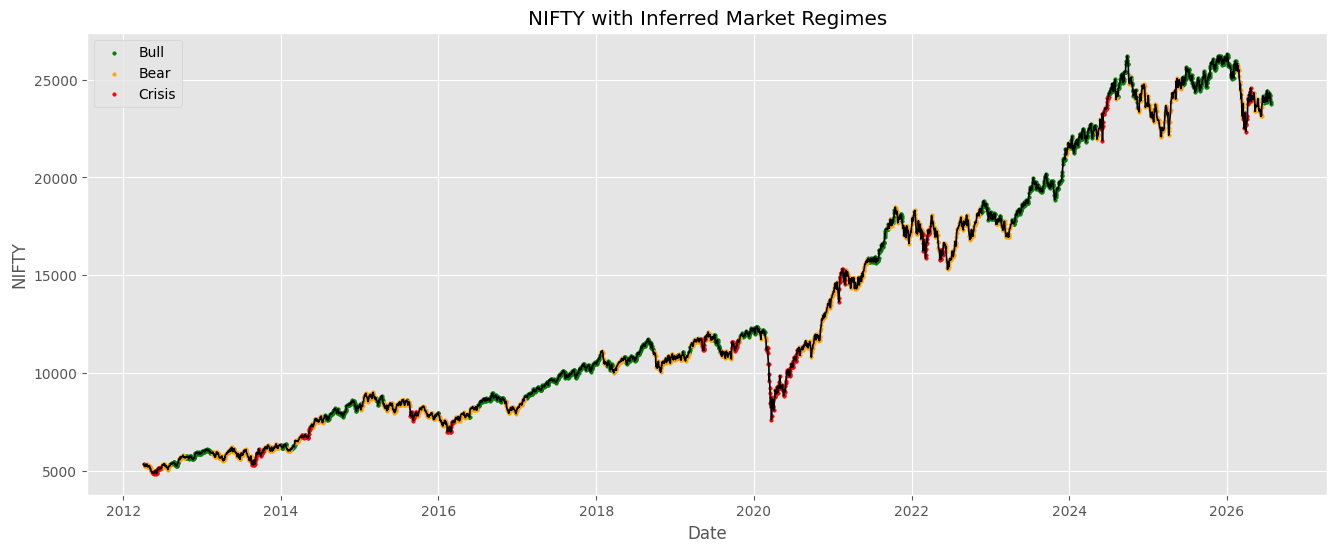

In [40]:
colors = {
    "Bull": "green",
    "Bear": "orange",
    "Crisis": "red"
}

plt.figure(figsize=(16, 6))

plt.plot(
    plot_data.index,
    plot_data["NIFTY"],
    color="black",
    linewidth=1.2
)

for regime, color in colors.items():

    mask = plot_data["regime"] == regime

    plt.scatter(
        plot_data.index[mask],
        plot_data["NIFTY"][mask],
        s=6,
        color=color,
        label=regime
    )

plt.title("NIFTY with Inferred Market Regimes")

plt.xlabel("Date")

plt.ylabel("NIFTY")

plt.legend()

plt.show()

# Part II: Walk-Forward Validation

The HMM is retrained using only past data to avoid lookahead bias. The resulting regimes are used for portfolio allocation and backtesting.

## 12. Walk-Forward Setup

In [41]:
# Parameters

TRAIN_YEARS = 5
TEST_MONTHS = 3

TRAIN_DAYS = TRAIN_YEARS * 252
TEST_DAYS = TEST_MONTHS * 21

In [42]:
print(f"Training Window : {TRAIN_DAYS} trading days")
print(f"Testing Window  : {TEST_DAYS} trading days")

Training Window : 1260 trading days
Testing Window  : 63 trading days


## 13. Containers for Results

In [85]:
predicted_states = []

predicted_dates = []

transition_matrices = []

## 14. Walk-Forward Validation and Portfolio Optimisation

An expanding-window walk-forward framework is used to avoid look-ahead bias.

For every training window:

- Features are standardised using only the training data.
- A Hidden Markov Model is trained.
- Hidden states are mapped to Bull, Bear and Crisis regimes.
- Expected returns and covariance matrices are estimated from the training data.
- CVXPY is used to compute optimal portfolio weights.
- The learned portfolio is applied to the next test window.

In [87]:
import cvxpy as cp

asset_names = ["NIFTY", "GOLD", "BOND"]

def optimise_portfolio(mu, sigma, regime):

    n = len(mu)

    w = cp.Variable(n)

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 1
    ]

    if regime == "Bull":
        gamma = 5

        objective = cp.Maximize(
            mu @ w - gamma * cp.quad_form(w, sigma)
        )

    elif regime == "Bear":

        gamma = 15

        objective = cp.Maximize(
            mu @ w - gamma * cp.quad_form(w, sigma)
        )

    else:

        objective = cp.Minimize(
            cp.quad_form(w, sigma)
        )

    problem = cp.Problem(objective, constraints)

    problem.solve(solver=cp.SCS, verbose=False)

    if w.value is None:
        return np.ones(n) / n

    return np.asarray(w.value).flatten()

In [88]:
# ==============================
# Walk-forward HMM + CVXPY Engine
# ==============================

portfolio_weights = pd.DataFrame(columns=asset_names)
strategy_returns = pd.Series(dtype=float)

for start in range(0, len(features) - TRAIN_DAYS - TEST_DAYS + 1, TEST_DAYS):

    # -----------------------------
    # Train / Test Split
    # -----------------------------
    train_features = features.iloc[start:start + TRAIN_DAYS]
    test_features = features.iloc[start + TRAIN_DAYS:start + TRAIN_DAYS + TEST_DAYS]

    train_returns = returns.loc[train_features.index, asset_names]
    test_returns = returns.loc[test_features.index, asset_names]

    # -----------------------------
    # Standardise
    # -----------------------------
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_features[
            ["ret","mom_5","mom_21","mom_63","vol_20","vix"]
        ]
    )

    X_test = scaler.transform(
        test_features[
            ["ret","mom_5","mom_21","mom_63","vol_20","vix"]
        ]
    )

    # -----------------------------
    # Train HMM
    # -----------------------------
    model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=500,
        random_state=42
    )

    model.fit(X_train)

    train_states = model.predict(X_train)
    test_states = model.predict(X_test)

    # -----------------------------
    # Label Regimes
    # -----------------------------
    state_vol = {}

    for s in range(3):

        idx = train_states == s

        if idx.sum() == 0:
            state_vol[s] = np.inf
        else:
            state_vol[s] = train_features.loc[idx, "vol_20"].mean()

    ordered = sorted(state_vol, key=state_vol.get)

    mapping = {
        ordered[0]: "Bull",
        ordered[1]: "Bear",
        ordered[2]: "Crisis"
    }

    # -----------------------------
    # Optimise once per regime
    # -----------------------------
    regime_weights = {}

    for regime in ["Bull", "Bear", "Crisis"]:

        state = [k for k,v in mapping.items() if v==regime][0]

        idx = train_states == state

        regime_ret = train_returns.loc[idx]

        # if too few samples, use all training data
        if len(regime_ret) < 20:
            regime_ret = train_returns

        mu = regime_ret.mean().values
        sigma = regime_ret.cov().values

        sigma = sigma + np.eye(len(asset_names))*1e-6

        regime_weights[regime] = optimise_portfolio(
            mu,
            sigma,
            regime
        )

    # -----------------------------
    # Apply weights on test window
    # -----------------------------
    for date, state in zip(test_returns.index, test_states):

        regime = mapping[state]

        w = regime_weights[regime]

        portfolio_weights.loc[date] = w

        strategy_returns.loc[date] = np.dot(
            test_returns.loc[date].values,
            w
        )

### Verification

The following checks verify that the optimisation produces valid portfolio weights and generates strategy returns for the entire walk-forward period.

In [89]:
print("Portfolio Weights Shape:")
print(portfolio_weights.shape)

print("\nStrategy Returns Shape:")
print(strategy_returns.shape)

print("\nFirst Five Portfolio Weights:")
display(portfolio_weights.head())

print("\nFirst Five Strategy Returns:")
display(strategy_returns.head())

Portfolio Weights Shape:
(2205, 3)

Strategy Returns Shape:
(2205,)

First Five Portfolio Weights:


,NIFTY,GOLD,BOND
2017-06-07,0.000672,0.000002,0.999325
2017-06-08,0.872383,0.000004,0.127612
2017-06-09,0.872383,0.000004,0.127612
2017-06-12,0.872383,0.000004,0.127612
2017-06-13,0.872383,0.000004,0.127612



First Five Strategy Returns:


,0
2017-06-07,0.000002
2017-06-08,-0.001503
2017-06-09,0.001899
2017-06-12,-0.004678
2017-06-13,-0.000862


In [90]:
print("Checking if weights sum to 1...")

weight_sum = portfolio_weights.sum(axis=1)

print(weight_sum.describe())

print("\nMaximum deviation from 1:")

print(np.abs(weight_sum - 1).max())

Checking if weights sum to 1...
count    2.205000e+03
mean     1.000000e+00
std      3.871060e-08
min      9.999996e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

Maximum deviation from 1:
4.2715859538411394e-07


count    2205.000000
mean        0.000520
std         0.006440
min        -0.105166
25%        -0.001078
50%         0.000104
75%         0.002201
max         0.078854
dtype: float64


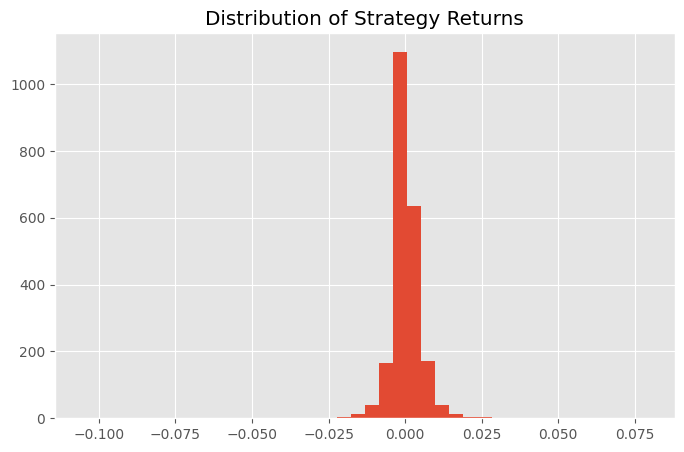

In [91]:
print(strategy_returns.describe())

strategy_returns.hist(figsize=(8,5), bins=40)

plt.title("Distribution of Strategy Returns")

plt.show()

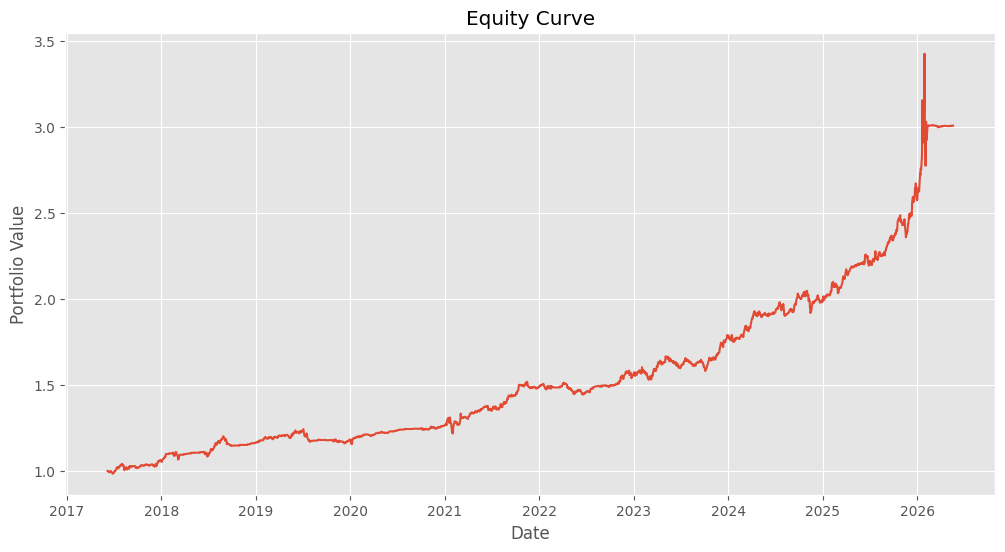

In [92]:
equity = (1 + strategy_returns).cumprod()

plt.figure(figsize=(12,6))

plt.plot(equity)

plt.title("Equity Curve")

plt.xlabel("Date")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

## 15. Transaction Costs

A transaction cost of 10 basis points is applied whenever the portfolio is rebalanced.

In [93]:
TRANSACTION_COST = 0.001      # 10 bps

In [94]:
# Portfolio turnover

turnover = portfolio_weights.diff().abs().sum(axis=1)

turnover.iloc[0] = 0

turnover.head()

,0
2017-06-07,0.000000
2017-06-08,1.743426
2017-06-09,0.000000
2017-06-12,0.000000
2017-06-13,0.000000


In [95]:
transaction_cost = turnover * TRANSACTION_COST

transaction_cost.head()

,0
2017-06-07,0.000000
2017-06-08,0.001743
2017-06-09,0.000000
2017-06-12,0.000000
2017-06-13,0.000000


In [96]:
strategy_returns_net = strategy_returns - transaction_cost

strategy_returns_net.head()

,0
2017-06-07,0.000002
2017-06-08,-0.003247
2017-06-09,0.001899
2017-06-12,-0.004678
2017-06-13,-0.000862


In [97]:
strategy_returns_net.describe()

,0
count,2205.000000
mean,0.000343
std,0.006452
min,-0.105166
25%,-0.001574
50%,0.000047
75%,0.002073
max,0.078854


## 16. Benchmark Portfolios

The strategy is compared against Equal Weight and a static 60/40 portfolio.

In [98]:
benchmark_returns = returns.loc[
    strategy_returns_net.index,
    ["NIFTY", "GOLD", "BOND"]
]

In [99]:
# Equal Weight Portfolio

equal_weights = np.array([1/3, 1/3, 1/3])

equal_weight_returns = benchmark_returns.dot(equal_weights)

In [100]:
# Static 60/40 Portfolio

weights_6040 = np.array([0.60, 0.00, 0.40])

portfolio_6040_returns = benchmark_returns.dot(weights_6040)

In [101]:
benchmark_df = pd.DataFrame({
    "Dynamic": strategy_returns_net,
    "Equal Weight": equal_weight_returns,
    "60/40": portfolio_6040_returns
})

benchmark_df.head()

,Dynamic,Equal Weight,60/40
2017-06-07,0.000002,0.000394,0.001665
2017-06-08,-0.003247,-0.001451,-0.001034
2017-06-09,0.001899,-0.001822,0.001306
2017-06-12,-0.004678,-0.002357,-0.003218
2017-06-13,-0.000862,-0.001431,-0.000593


## 17. Performance Evaluation

In [102]:
def sharpe_ratio(r):
    return np.sqrt(252) * r.mean() / r.std()


def sortino_ratio(r):
    downside = r[r < 0].std()
    return np.sqrt(252) * r.mean() / downside


def max_drawdown(r):
    wealth = (1 + r).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min()


def calmar_ratio(r):
    annual_return = (1 + r).prod() ** (252 / len(r)) - 1
    return annual_return / abs(max_drawdown(r))

In [103]:
performance = pd.DataFrame(index=benchmark_df.columns)

performance["Sharpe"] = benchmark_df.apply(sharpe_ratio)
performance["Sortino"] = benchmark_df.apply(sortino_ratio)
performance["Max Drawdown"] = benchmark_df.apply(max_drawdown)
performance["Calmar"] = benchmark_df.apply(calmar_ratio)

performance.loc["Dynamic", "Turnover"] = turnover.mean()

performance

,Sharpe,Sortino,Max Drawdown,Calmar,Turnover
Dynamic,0.844967,0.916643,-0.190131,0.445048,0.176754
Equal Weight,1.481809,1.799925,-0.159152,0.750672,NaN
60/40,0.838490,1.011979,-0.246672,0.333591,NaN


## 18. Equity Curve Comparison

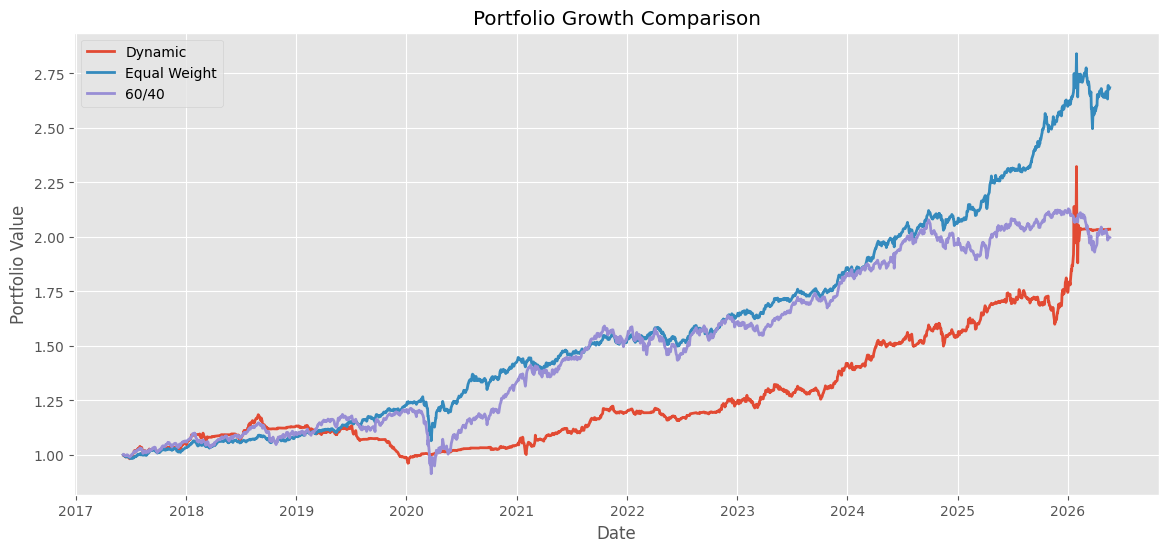

In [104]:
equity_curves = (1 + benchmark_df).cumprod()

plt.figure(figsize=(14,6))

for column in equity_curves.columns:
    plt.plot(
        equity_curves.index,
        equity_curves[column],
        label=column,
        linewidth=2
    )

plt.title("Portfolio Growth Comparison")

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend()

plt.show()